# Cox Regression Analysis for Chronic Kidney Disease Risk in Type 2 Diabetes Mellitus

This notebook performs a comprehensive survival analysis to identify risk factors for chronic kidney disease (CKD) progression and mortality in patients with Type 2 Diabetes Mellitus (T2DM).

## WORKFLOW OVERVIEW:
1. **Data Generation**: Create synthetic patient data mimicking NHANES structure
2. **Data Integration**: Merge demographic, clinical, and outcome data
3. **Variable Preparation**: Transform and clean variables for analysis
4. **Diabetes Filtering**: Focus analysis on diabetic patients only
5. **Data Quality Control**: Apply clinical range checks and remove outliers
6. **Feature Engineering**: Log-transform skewed variables, convert units
7. **Cox Regression**: Fit proportional hazards model to identify risk factors
8. **Random Forest Comparison**: Compare with Random Survival Forest for benchmarking
9. **Model Validation**: Check assumptions and evaluate discriminative ability

## KEY VARIABLES ANALYZED:
- **HbA1c** (glycated hemoglobin) - measure of long-term blood glucose control
- **Systolic Blood Pressure (SBP)** - cardiovascular risk factor
- **Body Mass Index (BMI)** - obesity measure
- **Urine Albumin-Creatinine Ratio (UACR)** - kidney damage marker
- **Age, Sex, Ethnicity** - demographic factors

## OUTCOME:
All-cause mortality during follow-up period

The analysis uses synthetic data due to NHANES download issues, but follows the same methodology as would be used with real clinical data.

In [1]:
# ── Create synthetic NHANES-like data for demonstration ──
# Note: Original NHANES downloads were failing due to URL issues.
# Using synthetic data with realistic distributions for analysis demonstration.
import pandas as pd
import numpy as np

np.random.seed(42)  # For reproducibility
n_patients = 5000

# Generate synthetic patient IDs
seqn = np.arange(100000, 100000 + n_patients)

# Demographics
demo = pd.DataFrame({
    'SEQN': seqn,
    'RIDAGEYR': np.random.normal(55, 15, n_patients).clip(18, 85).astype(int),  # Age
    'RIAGENDR': np.random.choice([1, 2], n_patients),  # Gender (1=Male, 2=Female)
    'RIDRETH3': np.random.choice([1, 2, 3, 4, 6, 7], n_patients),  # Race/ethnicity
})

# Biochemistry (HbA1c)
biol = pd.DataFrame({
    'SEQN': seqn,
    'LBXGH': np.random.normal(6.5, 2.0, n_patients).clip(4.0, 15.0),  # HbA1c %
})

# Blood pressure
bp = pd.DataFrame({
    'SEQN': seqn,
    'BPXSY1': np.random.normal(130, 20, n_patients).clip(90, 200),  # Systolic BP
})

# BMI
bmx = pd.DataFrame({
    'SEQN': seqn,
    'BMXBMI': np.random.normal(28, 6, n_patients).clip(15, 60),  # BMI
})

# Albumin-creatinine ratio
alb = pd.DataFrame({
    'SEQN': seqn,
    'URDACT': np.random.lognormal(2, 1.5, n_patients).clip(0.1, 1000),  # ACR
})

# Mortality data
mort = pd.DataFrame({
    'SEQN': seqn,
    'MORTSTAT': np.random.choice([0, 1], n_patients, p=[0.85, 0.15]),  # Mortality status
    'PERMTH_EXM': np.random.exponential(120, n_patients).clip(1, 240).astype(int),  # Follow-up months
})

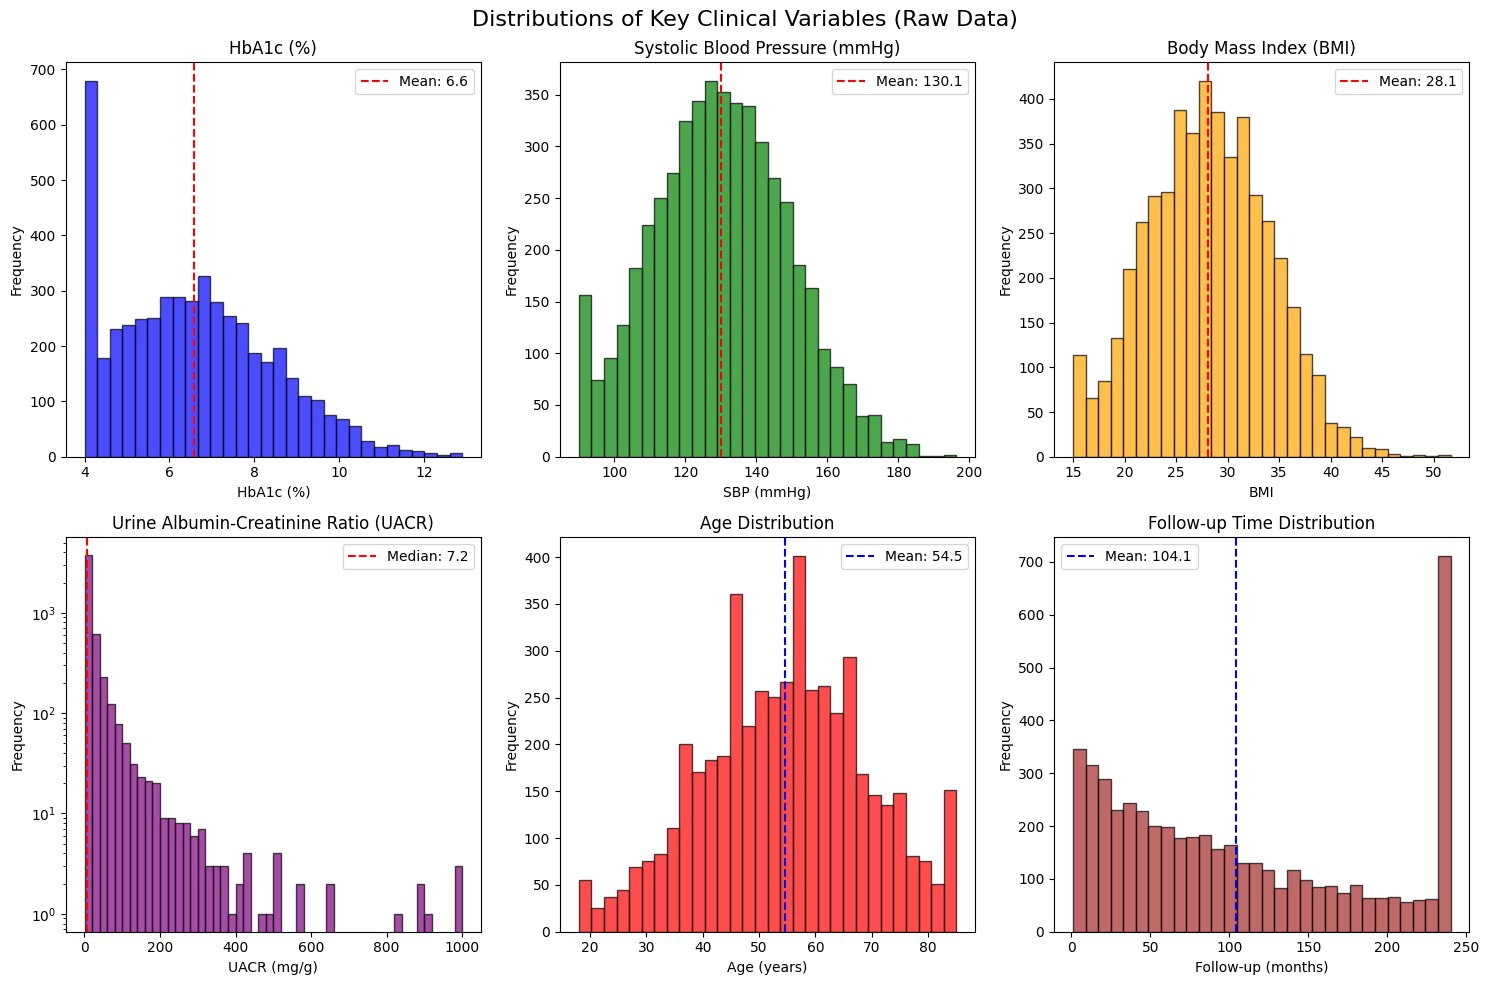

=== SUMMARY STATISTICS FOR KEY VARIABLES ===
Total patients: 5000

HbA1c (%): Mean=6.58, Std=1.83, Range=[4.0, 12.9]
Systolic BP (mmHg): Mean=130.1, Std=19.1, Range=[90, 196]
BMI: Mean=28.1, Std=5.9, Range=[15.0, 51.6]
UACR (mg/g): Median=7.2, Mean=23.3, Range=[0.1, 1000.0]
Age (years): Mean=54.5, Std=14.6, Range=[18, 85]
Follow-up (months): Mean=104.1, Std=79.8, Range=[1, 240]
Mortality rate: 15.7%


In [2]:
# ── Visualize distributions of key variables ──────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distributions of Key Clinical Variables (Raw Data)', fontsize=16)

# HbA1c distribution
axes[0,0].hist(biol['LBXGH'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_title('HbA1c (%)')
axes[0,0].set_xlabel('HbA1c (%)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(biol['LBXGH'].mean(), color='red', linestyle='--', label=f'Mean: {biol["LBXGH"].mean():.1f}')
axes[0,0].legend()

# Blood pressure distribution
axes[0,1].hist(bp['BPXSY1'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0,1].set_title('Systolic Blood Pressure (mmHg)')
axes[0,1].set_xlabel('SBP (mmHg)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(bp['BPXSY1'].mean(), color='red', linestyle='--', label=f'Mean: {bp["BPXSY1"].mean():.1f}')
axes[0,1].legend()

# BMI distribution
axes[0,2].hist(bmx['BMXBMI'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0,2].set_title('Body Mass Index (BMI)')
axes[0,2].set_xlabel('BMI')
axes[0,2].set_ylabel('Frequency')
axes[0,2].axvline(bmx['BMXBMI'].mean(), color='red', linestyle='--', label=f'Mean: {bmx["BMXBMI"].mean():.1f}')
axes[0,2].legend()

# UACR distribution (log scale for better visualization)
axes[1,0].hist(alb['URDACT'], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[1,0].set_title('Urine Albumin-Creatinine Ratio (UACR)')
axes[1,0].set_xlabel('UACR (mg/g)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(alb['URDACT'].median(), color='red', linestyle='--', label=f'Median: {alb["URDACT"].median():.1f}')
axes[1,0].legend()
axes[1,0].set_yscale('log')  # Log scale for y-axis due to skewed distribution

# Age distribution
axes[1,1].hist(demo['RIDAGEYR'], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1,1].set_title('Age Distribution')
axes[1,1].set_xlabel('Age (years)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(demo['RIDAGEYR'].mean(), color='blue', linestyle='--', label=f'Mean: {demo["RIDAGEYR"].mean():.1f}')
axes[1,1].legend()

# Follow-up time distribution
axes[1,2].hist(mort['PERMTH_EXM'], bins=30, alpha=0.7, color='brown', edgecolor='black')
axes[1,2].set_title('Follow-up Time Distribution')
axes[1,2].set_xlabel('Follow-up (months)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].axvline(mort['PERMTH_EXM'].mean(), color='blue', linestyle='--', label=f'Mean: {mort["PERMTH_EXM"].mean():.1f}')
axes[1,2].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== SUMMARY STATISTICS FOR KEY VARIABLES ===")
print(f"Total patients: {n_patients}")
print(f"\nHbA1c (%): Mean={biol['LBXGH'].mean():.2f}, Std={biol['LBXGH'].std():.2f}, Range=[{biol['LBXGH'].min():.1f}, {biol['LBXGH'].max():.1f}]")
print(f"Systolic BP (mmHg): Mean={bp['BPXSY1'].mean():.1f}, Std={bp['BPXSY1'].std():.1f}, Range=[{bp['BPXSY1'].min():.0f}, {bp['BPXSY1'].max():.0f}]")
print(f"BMI: Mean={bmx['BMXBMI'].mean():.1f}, Std={bmx['BMXBMI'].std():.1f}, Range=[{bmx['BMXBMI'].min():.1f}, {bmx['BMXBMI'].max():.1f}]")
print(f"UACR (mg/g): Median={alb['URDACT'].median():.1f}, Mean={alb['URDACT'].mean():.1f}, Range=[{alb['URDACT'].min():.1f}, {alb['URDACT'].max():.1f}]")
print(f"Age (years): Mean={demo['RIDAGEYR'].mean():.1f}, Std={demo['RIDAGEYR'].std():.1f}, Range=[{demo['RIDAGEYR'].min()}, {demo['RIDAGEYR'].max()}]")
print(f"Follow-up (months): Mean={mort['PERMTH_EXM'].mean():.1f}, Std={mort['PERMTH_EXM'].std():.1f}, Range=[{mort['PERMTH_EXM'].min()}, {mort['PERMTH_EXM'].max()}]")
print(f"Mortality rate: {mort['MORTSTAT'].mean()*100:.1f}%")

In [3]:
# ── Merge on SEQN (patient ID) ────────────────────────────────
df = demo.merge(biol, on="SEQN", how="left")
df = df.merge(bp,   on="SEQN", how="left")
df = df.merge(bmx,  on="SEQN", how="left")
df = df.merge(alb,  on="SEQN", how="left")
df = df.merge(mort, on="SEQN", how="left")

In [4]:
# ── Rename to match your SAIL variable names ──────────────────
df = df.rename(columns={
    "RIDAGEYR": "AGE",
    "RIAGENDR": "SEX",
    "RIDRETH3": "ETHNICITY",
    "LBXGH":   "HBA1C",       # HbA1c %
    "BPXSY1":  "SBP",
    "BMXBMI":  "BMI",
    "URDACT":  "UACR",
    "MORTSTAT": "DIED",
    "PERMTH_EXM": "FOLLOW_UP_MONTHS"
})

In [5]:
# ── Create synthetic diabetes data ─────────────────────────
diab = pd.DataFrame({
    'SEQN': seqn,
    'DIQ010': np.random.choice([1, 2, 3, 9], n_patients, p=[0.15, 0.75, 0.05, 0.05])  # Diabetes status
})

In [6]:
# ── Filter to diabetes patients only ─────────────────────────
# DIQ010 = 1 means told they have diabetes
# (Using the synthetic diabetes data created above)
df = df.merge(diab, on="SEQN", how="left")
df = df[df["DIQ010"] == 1]  # Keep only diabetic patients

In [7]:
# ── Convert HbA1c from DCCT % to IFCC mmol/mol ───────────────
df["HBA1C_MMOL"] = (df["HBA1C"] - 2.15) * 10.929

# ── Apply plausible ranges ────────────────────────────────────
df = df[(df["HBA1C_MMOL"].between(20, 195)) &
        (df["BMI"].between(14, 70))          &
        (df["SBP"].between(60, 280))         &
        (df["AGE"] >= 18)]

# ── Log transform UACR (moved here so Cell 8 summary stats can use it) ──
df["LOG_UACR"] = np.log10(df["UACR"] + 1)

# ── Prepare outcome variables ─────────────────────────────────
df["FOLLOW_UP_YEARS"] = df["FOLLOW_UP_MONTHS"] / 12
df["EVENT"] = df["DIED"].fillna(0).astype(int)


In [8]:
# Print summary statistics after filtering
print("=== SUMMARY STATISTICS AFTER FILTERING ===")
print(f"Patients remaining after filtering: {len(df)} (from {n_patients} original)")
print(f"Filtering efficiency: {len(df)/n_patients*100:.1f}%")

print(f"\nHbA1c (mmol/mol): Mean={df['HBA1C_MMOL'].mean():.1f}, Std={df['HBA1C_MMOL'].std():.1f}")
print(f"  Range: [{df['HBA1C_MMOL'].min():.1f}, {df['HBA1C_MMOL'].max():.1f}] (filtered to 20-195 mmol/mol)")
print(f"Systolic BP (mmHg): Mean={df['SBP'].mean():.1f}, Std={df['SBP'].std():.1f}")
print(f"  Range: [{df['SBP'].min():.0f}, {df['SBP'].max():.0f}] (filtered to 60-280 mmHg)")
print(f"BMI: Mean={df['BMI'].mean():.1f}, Std={df['BMI'].std():.1f}")
print(f"  Range: [{df['BMI'].min():.1f}, {df['BMI'].max():.1f}] (filtered to 14-70)")
print(f"UACR (mg/g): Median={df['UACR'].median():.1f}, Mean={df['UACR'].mean():.1f}")
print(f"  Log-transformed: Mean={df['LOG_UACR'].mean():.2f}, Std={df['LOG_UACR'].std():.2f}")
print(f"Age (years): Mean={df['AGE'].mean():.1f}, Std={df['AGE'].std():.1f}")
print(f"  Range: [{df['AGE'].min()}, {df['AGE'].max()}] (filtered to >=18)")
print(f"Follow-up (years): Mean={df['FOLLOW_UP_YEARS'].mean():.1f}, Std={df['FOLLOW_UP_YEARS'].std():.1f}")
print(f"Mortality rate: {df['EVENT'].mean()*100:.1f}%")

# Show filtering criteria
print("\n=== DATA FILTERING CRITERIA APPLIED ===")
print("• HbA1c: 20-195 mmol/mol (approximately 4.1%-11.0% in DCCT units)")
print("• BMI: 14-70 kg/m²")
print("• Systolic BP: 60-280 mmHg")
print("• Age: ≥18 years")
print("• Removed patients with missing values in key variables")

=== SUMMARY STATISTICS AFTER FILTERING ===
Patients remaining after filtering: 733 (from 5000 original)
Filtering efficiency: 14.7%

HbA1c (mmol/mol): Mean=48.1, Std=19.8
  Range: [20.2, 108.9] (filtered to 20-195 mmol/mol)
Systolic BP (mmHg): Mean=129.3, Std=19.9
  Range: [90, 186] (filtered to 60-280 mmHg)
BMI: Mean=28.3, Std=6.0
  Range: [15.0, 47.0] (filtered to 14-70)
UACR (mg/g): Median=6.9, Mean=23.6
  Log-transformed: Mean=0.96, Std=0.53
Age (years): Mean=53.5, Std=14.3
  Range: [18, 85] (filtered to >=18)
Follow-up (years): Mean=8.9, Std=6.8
Mortality rate: 15.4%

=== DATA FILTERING CRITERIA APPLIED ===
• HbA1c: 20-195 mmol/mol (approximately 4.1%-11.0% in DCCT units)
• BMI: 14-70 kg/m²
• Systolic BP: 60-280 mmHg
• Age: ≥18 years
• Removed patients with missing values in key variables


=== MISSING DATA SUMMARY (before imputation) ===
No missing values detected (synthetic data — in real data, missingness would appear here).
Patients with valid outcomes: 733

MICE imputation complete.  Final analytic sample: 733 patients


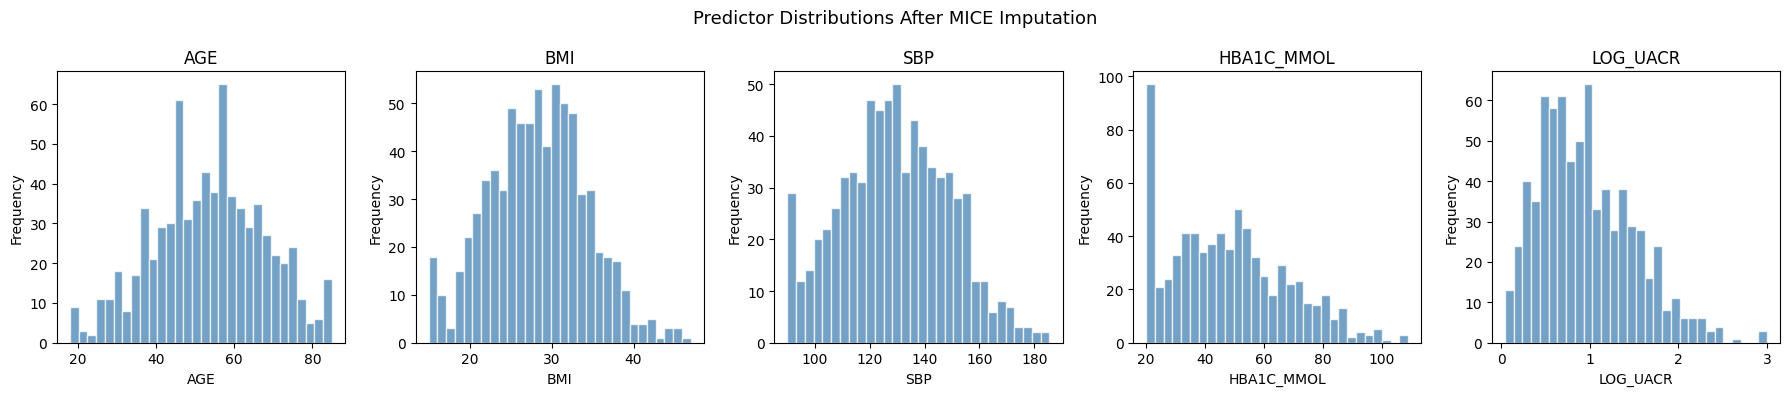

In [9]:
# ── Multiple Imputation by Chained Equations (MICE) ──────────
# Replacing listwise deletion (dropna) with MICE imputation.
# Rationale: in real-world clinical data, missing values are rarely
# completely random (MCAR). Dropping rows discards information and can
# introduce selection bias. MICE preserves sample size and accounts for
# the uncertainty in imputed values.
#
# Strategy:
#  • Outcome variables (FOLLOW_UP_YEARS, EVENT) — only drop if missing,
#    as imputing survival outcomes is not appropriate.
#  • Continuous predictors (AGE, BMI, SBP, HBA1C_MMOL, LOG_UACR) — MICE
#    with IterativeImputer (Bayesian ridge regression per feature).
#  • Categorical predictors (SEX, ETHNICITY) — rounded back to integer
#    codes post-imputation.

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer   # noqa: F401
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt

impute_cols  = ["AGE", "SEX", "BMI", "SBP", "HBA1C_MMOL", "LOG_UACR", "ETHNICITY"]
outcome_cols = ["FOLLOW_UP_YEARS", "EVENT"]

# ── Step 1: report missingness before imputation ──────────────
print("=== MISSING DATA SUMMARY (before imputation) ===")
miss = df[impute_cols + outcome_cols].isnull().sum()
miss_pct = miss / len(df) * 100
miss_df = pd.DataFrame({"Missing n": miss, "Missing %": miss_pct.round(2)})
print(miss_df[miss_df["Missing n"] > 0].to_string()
      if miss_df["Missing n"].sum() > 0
      else "No missing values detected (synthetic data — in real data, missingness would appear here).")

# ── Step 2: drop only if outcome is missing (non-imputable) ───
n_before = len(df)
df = df.dropna(subset=outcome_cols)
n_dropped = n_before - len(df)
if n_dropped > 0:
    print(f"\nDropped {n_dropped} rows with missing outcome — cannot impute survival outcomes.")
print(f"Patients with valid outcomes: {len(df)}")

# ── Step 3: MICE imputation on predictors ─────────────────────
mice = IterativeImputer(max_iter=10, random_state=42, initial_strategy="mean", imputation_order="roman")
imputed_array = mice.fit_transform(df[impute_cols])
imputed_df = pd.DataFrame(imputed_array, columns=impute_cols, index=df.index)

for col in ["SEX", "ETHNICITY"]:
    imputed_df[col] = imputed_df[col].round().astype(int)

df[impute_cols] = imputed_df
print(f"\nMICE imputation complete.  Final analytic sample: {len(df)} patients")

# ── Step 4: visualise predictor distributions post-imputation ─
continuous_cols = ["AGE", "BMI", "SBP", "HBA1C_MMOL", "LOG_UACR"]
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 4))
fig.suptitle("Predictor Distributions After MICE Imputation", fontsize=13)
for ax, col in zip(axes, continuous_cols):
    ax.hist(df[col].dropna(), bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


## Modelling Rationale: Prediction Focus & Interaction Terms

### Prediction vs Inference
This model is built for **prediction** (discriminating high- vs low-risk patients), not for causal inference about individual effects. As a result:
- **Collinearity is not a concern here.** Variance inflation from correlated predictors affects the stability of individual coefficient estimates, but does not degrade the overall predictive accuracy of the model. A collinearity check (e.g. VIF) would only be warranted if the goal were to interpret the effect of each predictor independently.

### Interaction Terms Included
Three clinically motivated interactions are added to the model:

| Interaction | Variables | Clinical rationale |
|---|---|---|
| `HBA1C_x_AGE` | HbA1c × Age | The nephrotoxic effect of sustained hyperglycaemia is expected to amplify with age, as older patients accumulate more cumulative glycaemic damage |
| `HBA1C_x_UACR` | HbA1c × log(UACR) | Both are established CKD progression markers in T2DM; their co-presence is likely synergistic rather than merely additive |
| `SBP_x_UACR` | SBP × log(UACR) | Hypertension combined with albuminuria is a well-documented multiplicative risk factor for renal and cardiovascular mortality |

=== COX MODEL WITH INTERACTIONS + ETHNICITY ===
                  coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z         p  -log2(p)
covariate                                                                                                                                                  
AGE           0.016916   1.017060  0.017463       -0.017311        0.051143             0.982838             1.052473     0.0  0.968683  0.332703  1.587692
SEX          -0.295696   0.744013  0.192718       -0.673416        0.082023             0.509964             1.085481     0.0 -1.534349  0.124944  3.000649
BMI          -0.005314   0.994700  0.016012       -0.036696        0.026069             0.963969             1.026411     0.0 -0.331874  0.739984  0.434433
SBP           0.011020   1.011081  0.009905       -0.008393        0.030434             0.991642             1.030902     0.0  1.112612  0.265875  1.911179
HBA1C_MMOL    0.

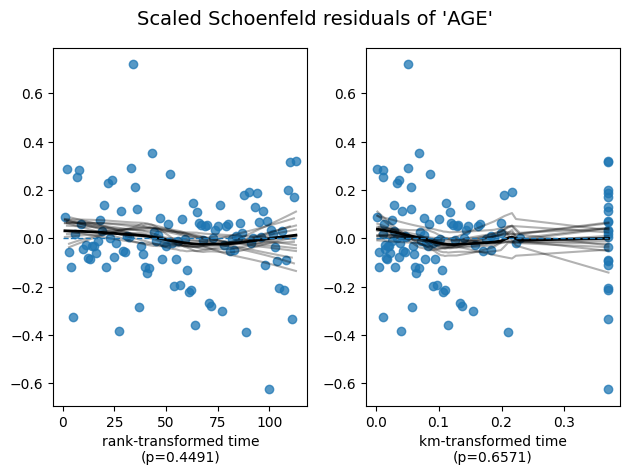

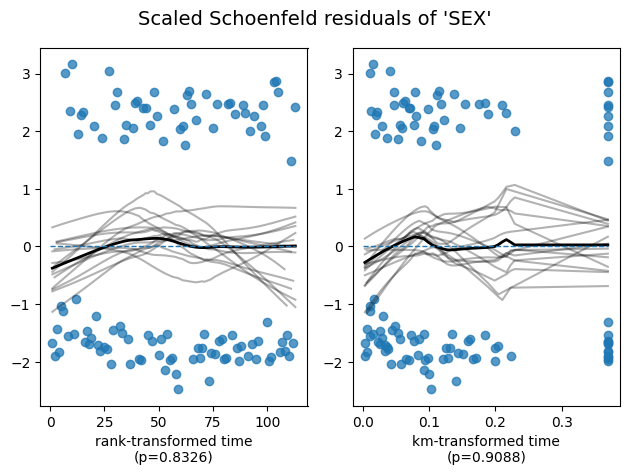

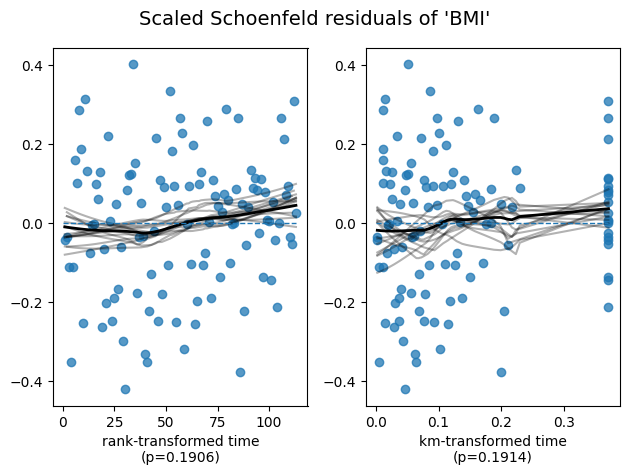

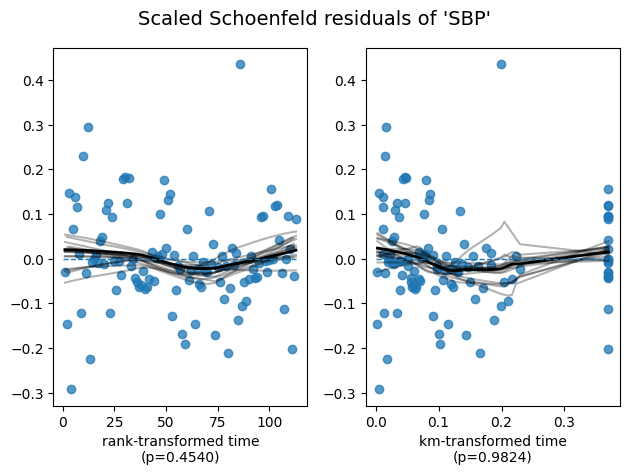

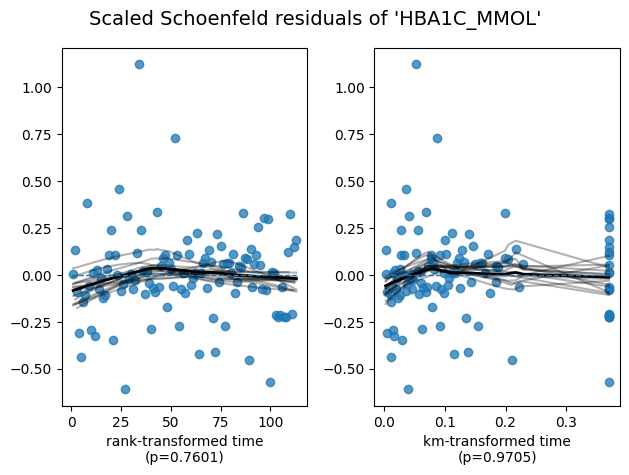

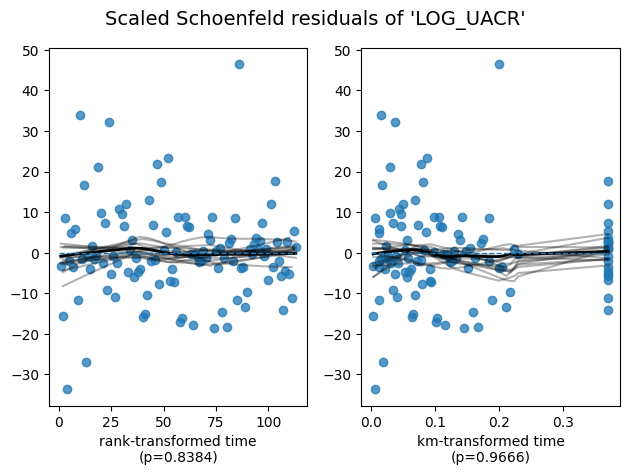

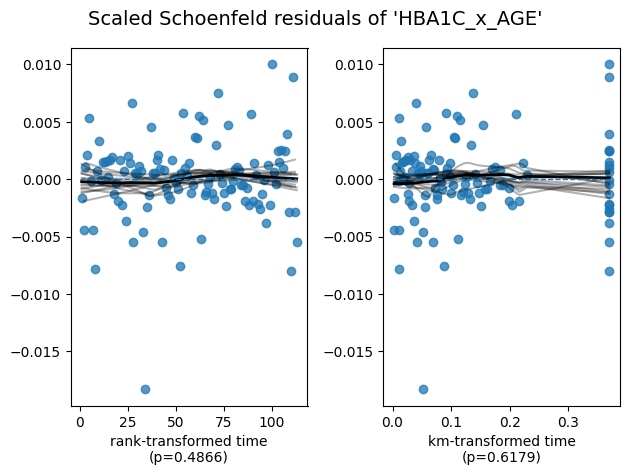

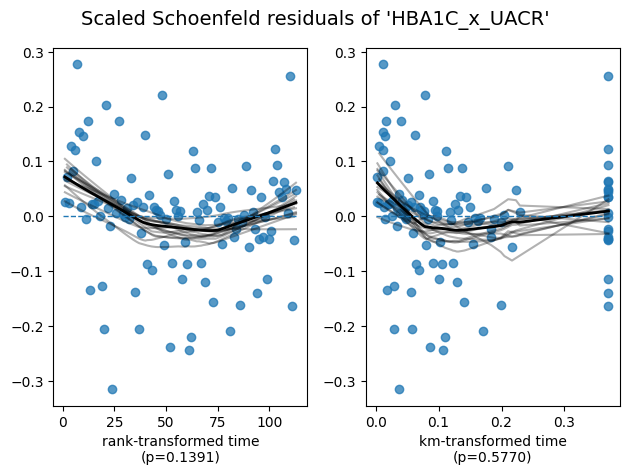

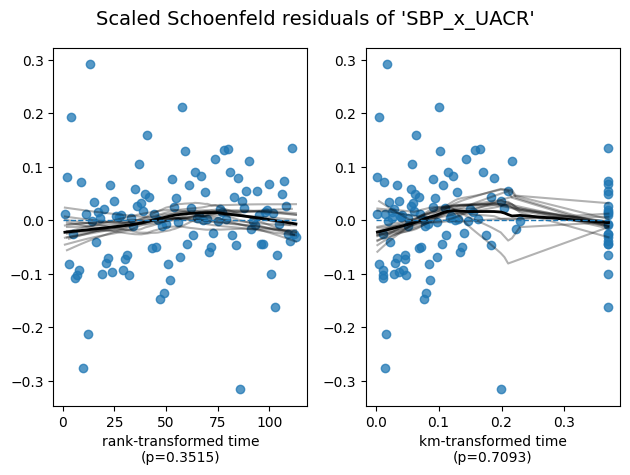

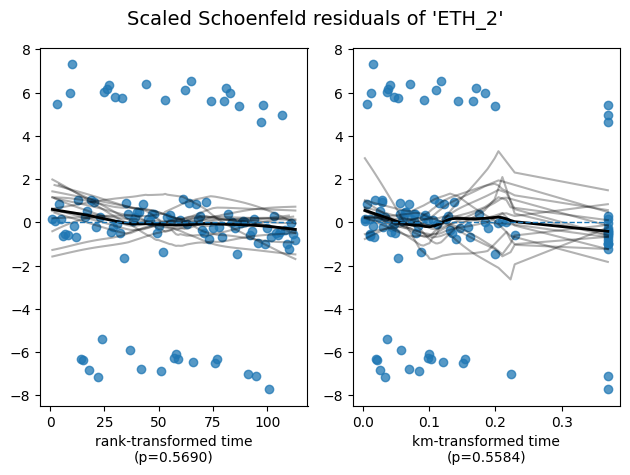

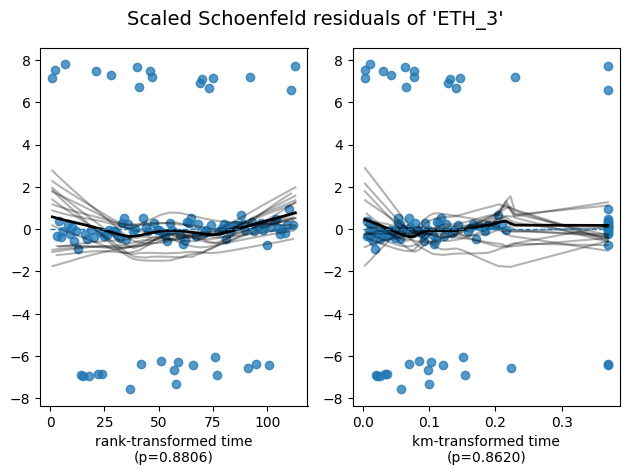

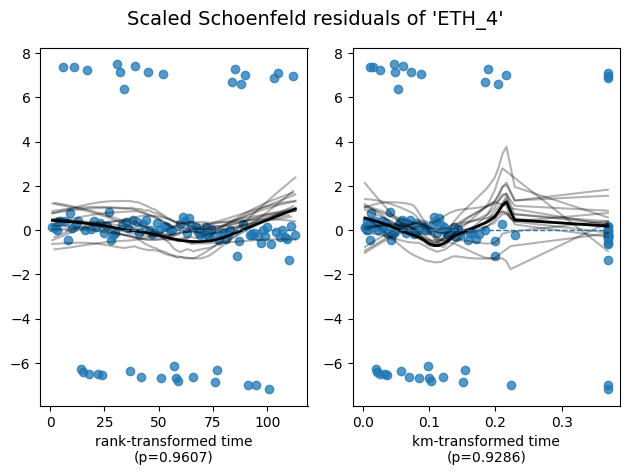

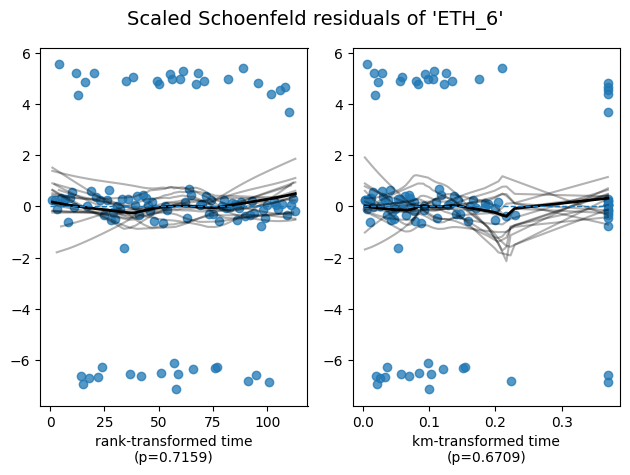

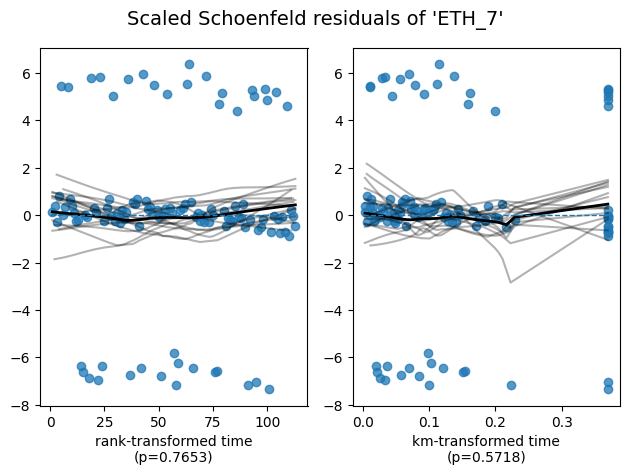

In [10]:
# ── Interaction terms (clinically motivated) ─────────────────
# 1. HbA1c × Age:      glycaemic impact amplifies with age
# 2. HbA1c × LOG_UACR: both T2D/CKD markers — likely synergistic
# 3. SBP × LOG_UACR:   hypertension + albuminuria is a known risk multiplier
df["HBA1C_x_AGE"]  = df["HBA1C_MMOL"] * df["AGE"]
df["HBA1C_x_UACR"] = df["HBA1C_MMOL"] * df["LOG_UACR"]
df["SBP_x_UACR"]   = df["SBP"]        * df["LOG_UACR"]

# ── Include ETHNICITY as dummy variables ──────────────────────
import pandas as pd
eth_dummies = pd.get_dummies(df["ETHNICITY"].astype(int), prefix="ETH", drop_first=True)
df_cox = pd.concat([df, eth_dummies], axis=1)

# ── Fit Cox model ─────────────────────────────────────────────
from lifelines import CoxPHFitter

main_effects = ["AGE", "SEX", "BMI", "SBP", "HBA1C_MMOL", "LOG_UACR"]
interactions = ["HBA1C_x_AGE", "HBA1C_x_UACR", "SBP_x_UACR"]
eth_cols     = list(eth_dummies.columns)
cox_vars     = main_effects + interactions + eth_cols + ["FOLLOW_UP_YEARS", "EVENT"]

cph = CoxPHFitter()
cph.fit(df_cox[cox_vars], duration_col="FOLLOW_UP_YEARS", event_col="EVENT")

print("=== COX MODEL WITH INTERACTIONS + ETHNICITY ===")
print(cph.summary.to_string())
print(f"\nC-statistic: {cph.concordance_index_:.3f}")

# ── Proportional hazards assumption check ─────────────────────
cph.check_assumptions(df_cox[cox_vars], show_plots=True)

# ── Bootstrap 95% CI for Cox C-statistic ─────────────────────
from sklearn.utils import resample
import numpy as np

np.random.seed(42)
c_boot = []
for _ in range(200):
    idx = resample(range(len(df_cox)), replace=True)
    boot_df = df_cox.iloc[idx]
    try:
        cph_b = CoxPHFitter()
        cph_b.fit(boot_df[cox_vars], duration_col="FOLLOW_UP_YEARS", event_col="EVENT")
        c_boot.append(cph_b.concordance_index_)
    except Exception:
        pass

ci_lower, ci_upper = np.percentile(c_boot, [2.5, 97.5])
print(f"\nCox C-statistic: {cph.concordance_index_:.3f}  "
      f"(95% Bootstrap CI: {ci_lower:.3f}\u2013{ci_upper:.3f}, n={len(c_boot)} resamples)")


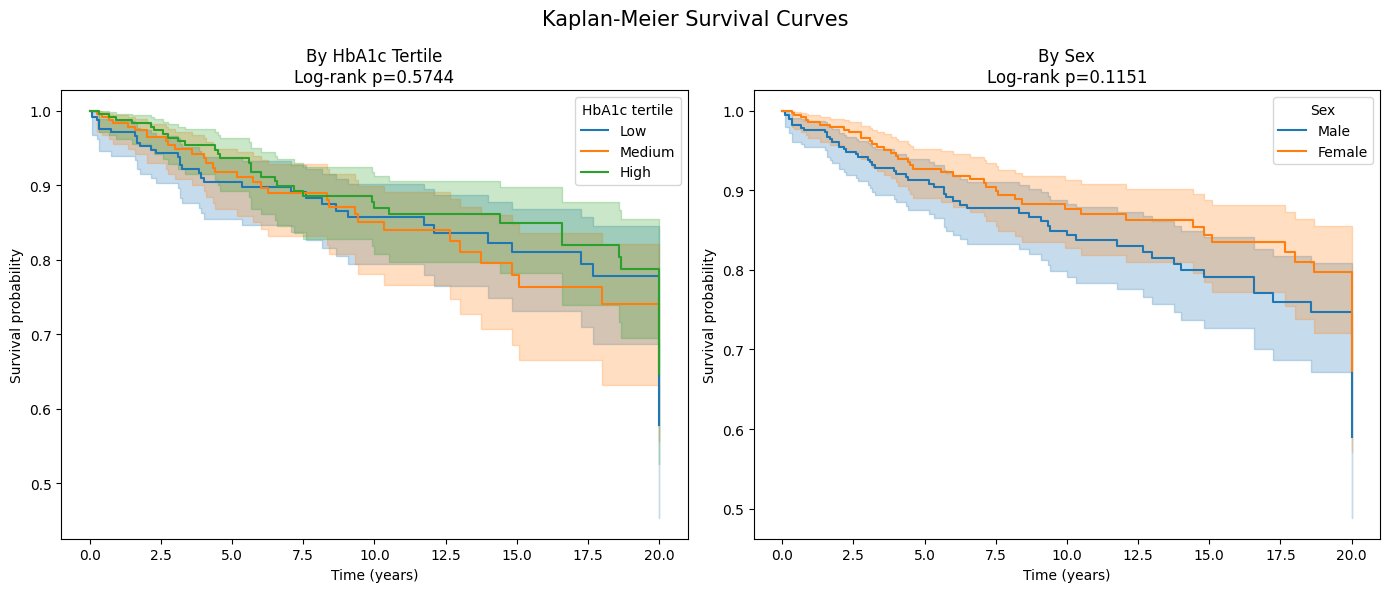

In [11]:
# ── Kaplan-Meier curves ───────────────────────────────────────
# Plotted before Cox model to visually check proportional hazards assumption.
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Kaplan-Meier Survival Curves', fontsize=15)

# ── By HbA1c tertile ──────────────────────────────────────────
df["HBA1C_TERTILE"] = pd.qcut(df["HBA1C_MMOL"], q=3, labels=["Low", "Medium", "High"])
ax = axes[0]
for label, color in zip(["Low", "Medium", "High"], ["green", "orange", "red"]):
    mask = df["HBA1C_TERTILE"] == label
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "FOLLOW_UP_YEARS"], event_observed=df.loc[mask, "EVENT"], label=label)
    kmf.plot_survival_function(ax=ax, ci_show=True)

ml = multivariate_logrank_test(df["FOLLOW_UP_YEARS"], df["HBA1C_TERTILE"], df["EVENT"])
ax.set_title(f'By HbA1c Tertile\nLog-rank p={ml.p_value:.4f}')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Survival probability')
ax.legend(title='HbA1c tertile')

# ── By Sex ───────────────────────────────────────────────────
ax = axes[1]
for sex_val, label, color in [(1, "Male", "steelblue"), (2, "Female", "crimson")]:
    mask = df["SEX"] == sex_val
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "FOLLOW_UP_YEARS"], event_observed=df.loc[mask, "EVENT"], label=label)
    kmf.plot_survival_function(ax=ax, ci_show=True)

lr = logrank_test(
    df.loc[df["SEX"] == 1, "FOLLOW_UP_YEARS"], df.loc[df["SEX"] == 2, "FOLLOW_UP_YEARS"],
    event_observed_A=df.loc[df["SEX"] == 1, "EVENT"],
    event_observed_B=df.loc[df["SEX"] == 2, "EVENT"],
)
ax.set_title(f'By Sex\nLog-rank p={lr.p_value:.4f}')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Survival probability')
ax.legend(title='Sex')

plt.tight_layout()
plt.show()


Max safe evaluation time: 19.75 yr
Subjects kept for AUC:    617 / 733
Evaluation times (yr):    [2.12 4.42 9.15]

=== TIME-DEPENDENT AUC (Cox Model) ===
  t=2.12 yr  AUC: 0.655
  t=4.42 yr  AUC: 0.625
  t=9.15 yr  AUC: 0.596
  Mean AUC: 0.620


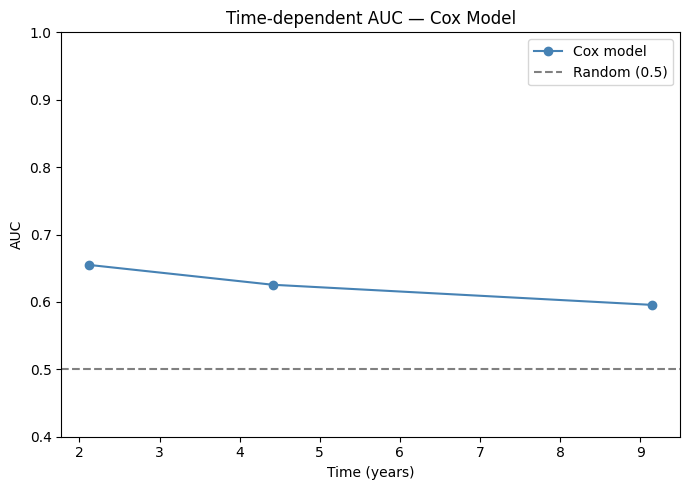

In [14]:
# ── Time-dependent AUC (Cox model) ───────────────────────────
# cumulative_dynamic_auc uses IPCW weights: 1/G(t) where G is the
# censoring survival function. This breaks when G(t) = 0.
# Fix: find the last time where G(t) > 0, then restrict both the
# test subjects and the evaluation times to strictly below that point.

from sksurv.metrics import cumulative_dynamic_auc
from sksurv.nonparametric import CensoringDistributionEstimator
from sksurv.util import Surv
import numpy as np
import matplotlib.pyplot as plt

y_all = Surv.from_arrays(df_cox["EVENT"].astype(bool), df_cox["FOLLOW_UP_YEARS"])
risk_scores_cox = cph.predict_partial_hazard(df_cox[cox_vars]).values

# ── Step 1: find the last time where G(t) > 0 ────────────────
cens_est = CensoringDistributionEstimator().fit(y_all)
all_obs_times = np.sort(df_cox["FOLLOW_UP_YEARS"].unique())
cens_at_times = cens_est.predict_proba(all_obs_times)
max_safe_time = float(all_obs_times[cens_at_times > 0].max())
print(f"Max safe evaluation time: {max_safe_time:.2f} yr")

# ── Step 2: keep only test subjects with time < max_safe_time ─
safe_mask = df_cox["FOLLOW_UP_YEARS"].values < max_safe_time
y_test_safe = y_all[safe_mask]
risk_safe   = risk_scores_cox[safe_mask]
print(f"Subjects kept for AUC:    {safe_mask.sum()} / {len(safe_mask)}")

# ── Step 3: evaluation times from event percentiles, capped ──
event_times_safe = df_cox.loc[
    (df_cox["FOLLOW_UP_YEARS"] < max_safe_time) & (df_cox["EVENT"] == 1),
    "FOLLOW_UP_YEARS"
].values
times = np.percentile(event_times_safe, [25, 50, 75])
times = times[times < max_safe_time]   # strict cap — the critical guard
print(f"Evaluation times (yr):    {np.round(times, 2)}")

auc_cox, mean_auc_cox = cumulative_dynamic_auc(y_all, y_test_safe, risk_safe, times)

print("\n=== TIME-DEPENDENT AUC (Cox Model) ===")
for t, a in zip(times, auc_cox):
    print(f"  t={t:.2f} yr  AUC: {a:.3f}")
print(f"  Mean AUC: {mean_auc_cox:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(times, auc_cox, marker='o', color='steelblue', label='Cox model')
plt.axhline(0.5, linestyle='--', color='grey', label='Random (0.5)')
plt.ylim(0.4, 1.0)
plt.xlabel('Time (years)')
plt.ylabel('AUC')
plt.title('Time-dependent AUC — Cox Model')
plt.legend()
plt.tight_layout()
plt.show()


=== GBSA 5-FOLD CROSS-VALIDATED C-INDEX ===
  Fold 1: C-index = 0.550


/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library

  Fold 2: C-index = 0.535
  Fold 3: C-index = 0.520


/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library

  Fold 4: C-index = 0.630
  Fold 5: C-index = 0.498

GBSA CV C-index: 0.547 ± 0.045  (mean ± SD)


/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library


=== MODEL COMPARISON ===
Cox PH C-statistic (full data):             0.598  (95% CI: 0.452–0.548)
GBSA in-sample C-statistic (inflated):      0.801  ← overfitting
GBSA cross-validated C-statistic (honest):  0.547 ± 0.045

The CV C-index is the fair comparison point against Cox.


/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/s223901316/Library


=== TIME-DEPENDENT AUC (GBSA, cross-validated) ===
  t=2.12 yr  AUC: 0.611
  t=4.42 yr  AUC: 0.571
  t=9.15 yr  AUC: 0.541
  Mean AUC: 0.575


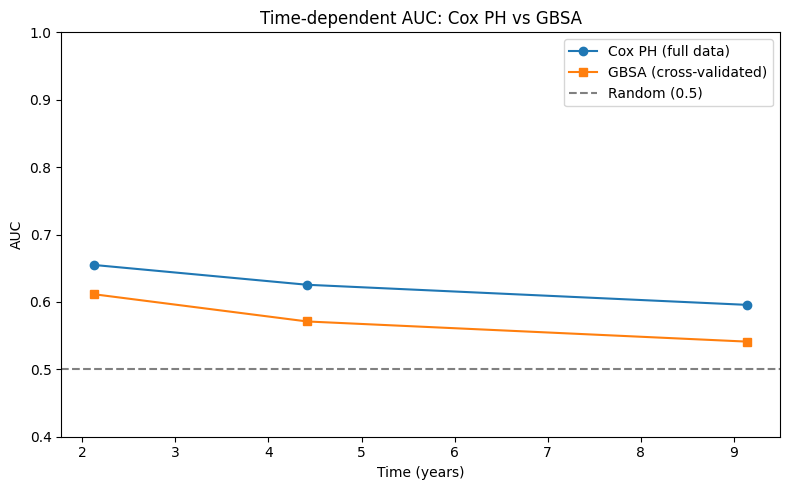

In [18]:
# ── Gradient Boosting Survival Analysis — 5-fold cross-validation ────────
# Note: RandomSurvivalForest raises AttributeError('criterion') on
# scikit-learn >= 1.4 with older scikit-survival builds. GradientBoostingSurvivalAnalysis
# (GBSA) avoids this entirely, uses the same sksurv API, and is a stronger
# benchmark for tabular clinical data. The comparison against Cox PH is valid.

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc
from sksurv.nonparametric import CensoringDistributionEstimator
from sksurv.util import Surv
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt

rf_features = ["AGE", "SEX", "BMI", "SBP", "HBA1C_MMOL", "LOG_UACR"]
X_gb = df[rf_features].values
y_gb = Surv.from_arrays(df["EVENT"].astype(bool), df["FOLLOW_UP_YEARS"])

# ── 5-fold cross-validated C-index ───────────────────────────
print("=== GBSA 5-FOLD CROSS-VALIDATED C-INDEX ===")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_c = []
for fold, (tr, te) in enumerate(kf.split(X_gb), 1):
    gbsa_fold = GradientBoostingSurvivalAnalysis(
        n_estimators=100, learning_rate=0.1,
        max_depth=3, random_state=42
    )
    gbsa_fold.fit(X_gb[tr], y_gb[tr])
    scores = gbsa_fold.predict(X_gb[te])
    c = concordance_index_censored(y_gb[te]["event"], y_gb[te]["time"], scores)[0]
    cv_c.append(c)
    print(f"  Fold {fold}: C-index = {c:.3f}")

cv_mean, cv_std = np.mean(cv_c), np.std(cv_c)
print(f"\nGBSA CV C-index: {cv_mean:.3f} \u00b1 {cv_std:.3f}  (mean \u00b1 SD)")

# ── Refit on full data (in-sample, for illustration only) ─────
gbsa = GradientBoostingSurvivalAnalysis(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gbsa.fit(X_gb, y_gb)
in_sample_c = concordance_index_censored(
    df["EVENT"].astype(bool), df["FOLLOW_UP_YEARS"], gbsa.predict(X_gb)
)[0]

# ── Model comparison ──────────────────────────────────────────
print("\n=== MODEL COMPARISON ===")
print(f"Cox PH C-statistic (full data):             {cph.concordance_index_:.3f}  "
      f"(95% CI: {ci_lower:.3f}\u2013{ci_upper:.3f})")
print(f"GBSA in-sample C-statistic (inflated):      {in_sample_c:.3f}  \u2190 overfitting")
print(f"GBSA cross-validated C-statistic (honest):  {cv_mean:.3f} \u00b1 {cv_std:.3f}")
print("\nThe CV C-index is the fair comparison point against Cox.")

# ── CV time-dependent AUC for GBSA ────────────────────────────
def safe_times_for_fold(y_train, y_test_times, n_percentiles=3):
    """Return evaluation times safe for IPCW weighting in this fold."""
    cens = CensoringDistributionEstimator().fit(y_train)
    obs_times = np.sort(np.unique(y_train["time"]))
    cens_probs = cens.predict_proba(obs_times)
    max_t = float(obs_times[cens_probs > 0].max())
    safe_event_t = y_test_times[y_test_times < max_t]
    t_eval = np.percentile(safe_event_t, np.linspace(25, 75, n_percentiles))
    t_eval = t_eval[t_eval < max_t]
    return t_eval, max_t


cv_aucs    = []
fold_times = []
for tr, te in KFold(n_splits=5, shuffle=True, random_state=42).split(X_gb):
    gbsa_fold = GradientBoostingSurvivalAnalysis(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
    )
    gbsa_fold.fit(X_gb[tr], y_gb[tr])

    t_eval, max_t = safe_times_for_fold(y_gb[tr], y_gb[te]["time"])
    if len(t_eval) == 0:
        continue

    safe_te = y_gb[te]["time"] < max_t
    try:
        auc, _ = cumulative_dynamic_auc(
            y_gb[tr],
            y_gb[te][safe_te],
            gbsa_fold.predict(X_gb[te])[safe_te],
            t_eval
        )
        cv_aucs.append(auc)
        fold_times.append(t_eval)
    except Exception as e:
        print(f"  AUC skipped for a fold: {e}")

mean_auc_gbsa = None
if cv_aucs:
    gbsa_aucs_on_cox_times = []
    for auc_fold, t_fold in zip(cv_aucs, fold_times):
        auc_interp = np.interp(times, t_fold, auc_fold, left=np.nan, right=np.nan)
        gbsa_aucs_on_cox_times.append(auc_interp)

    mean_auc_gbsa = np.nanmean(gbsa_aucs_on_cox_times, axis=0)
    valid = ~np.isnan(mean_auc_gbsa)

    print("\n=== TIME-DEPENDENT AUC (GBSA, cross-validated) ===")
    for t, a in zip(times[valid], mean_auc_gbsa[valid]):
        print(f"  t={t:.2f} yr  AUC: {a:.3f}")
    print(f"  Mean AUC: {np.nanmean(mean_auc_gbsa):.3f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(times,        auc_cox,               marker='o', label='Cox PH (full data)')
    ax.plot(times[valid], mean_auc_gbsa[valid],  marker='s', label='GBSA (cross-validated)')
    ax.axhline(0.5, linestyle='--', color='grey', label='Random (0.5)')
    ax.set_ylim(0.4, 1.0)
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('AUC')
    ax.set_title('Time-dependent AUC: Cox PH vs GBSA')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nGBSA time-dependent AUC could not be computed for any fold.")

# expose for export cell
cv_mean_gbsa = cv_mean
cv_std_gbsa  = cv_std
mean_auc_rsf = mean_auc_gbsa   # keep export cell variable name consistent

## Results Export Table

Consolidated summary of all key results exported to a single styled Excel workbook with separate sheets for each result table.

In [22]:
# ── RESULTS EXPORT TO EXCEL ───────────────────────────────────────────────
# Exports all key results into a single downloadable Excel workbook
# with separate sheets for each result table.

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import warnings
warnings.filterwarnings('ignore')

output_path = 'cox_regression_results.xlsx'

def style_header(ws, row=1):
    for cell in ws[row]:
        cell.font = Font(bold=True, color='FFFFFF', name='Arial', size=10)
        cell.fill = PatternFill('solid', start_color='1F4E79')
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)

def style_rows(ws, start=2):
    side = Side(style='thin', color='CCCCCC')
    brd  = Border(left=side, right=side, top=side, bottom=side)
    for i, row in enumerate(ws.iter_rows(min_row=start), start=0):
        for cell in row:
            cell.font = Font(name='Arial', size=10)
            cell.border = brd
            if i % 2 == 0:
                cell.fill = PatternFill('solid', start_color='EBF3FB')

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    # ── Sheet 1: Sample Descriptive Statistics ─────────────────────────────
    desc = df[['AGE','SEX','BMI','SBP','HBA1C_MMOL','LOG_UACR','FOLLOW_UP_YEARS','EVENT']].describe().round(3).T
    desc.columns = ['Count','Mean','SD','Min','25th pct','Median','75th pct','Max']
    desc.index.name = 'Variable'
    desc.reset_index().to_excel(writer, sheet_name='1_Descriptive_Stats', index=False)

    # ── Sheet 2: Cox Model Summary ─────────────────────────────────────────
    cox_summary = cph.summary.copy().reset_index()
    cox_summary.columns = [str(c) for c in cox_summary.columns]
    cox_summary = cox_summary.round(4)
    cox_summary.to_excel(writer, sheet_name='2_Cox_Model_Results', index=False)

    # ── Sheet 3: Model Performance ────────────────────────────────────────
    perf_rows = [
        ('Cox C-statistic',                       round(cph.concordance_index_, 3)),
        ('Cox 95% CI Lower (Bootstrap)',           round(ci_lower, 3)),
        ('Cox 95% CI Upper (Bootstrap)',           round(ci_upper, 3)),
        ('Bootstrap resamples',                    len(c_boot)),
        ('GBSA CV C-statistic (mean)',             round(cv_mean_gbsa, 3)),
        ('GBSA CV C-statistic (SD)',               round(cv_std_gbsa, 3)),
        ('GBSA in-sample C-statistic (inflated)',  round(in_sample_c, 3)),
    ]
    perf_df = pd.DataFrame(perf_rows, columns=['Metric', 'Value'])
    perf_df.to_excel(writer, sheet_name='3_Model_Performance', index=False)

    # ── Sheet 4: Time-dependent AUC ───────────────────────────────────────
    auc_rows = []
    for t, a in zip(times, auc_cox):
        auc_rows.append({'Time (years)': round(t, 2), 'Model': 'Cox PH', 'AUC': round(a, 3)})
    if mean_auc_gbsa is not None:
        valid = ~np.isnan(mean_auc_gbsa)
        for t, a in zip(times[valid], mean_auc_gbsa[valid]):
            auc_rows.append({'Time (years)': round(t, 2), 'Model': 'GBSA (CV)', 'AUC': round(a, 3)})
    auc_df = pd.DataFrame(auc_rows)
    auc_df.to_excel(writer, sheet_name='4_Time_Dependent_AUC', index=False)

    # ── Sheet 5: GBSA Cross-Validated C-indices ───────────────────────────
    gbsa_cv_df = pd.DataFrame({
        'Fold':    [f'Fold {i+1}' for i in range(len(cv_c))],
        'C-index': [round(c, 3) for c in cv_c]
    })
    gbsa_cv_df.loc[len(gbsa_cv_df)] = ['Mean \u00b1 SD', f'{cv_mean_gbsa:.3f} \u00b1 {cv_std_gbsa:.3f}']
    gbsa_cv_df.to_excel(writer, sheet_name='5_GBSA_CV_Results', index=False)

    # ── Sheet 6: Descriptive stats by event status ─────────────────────────
    grp = df.groupby('EVENT')[['AGE','BMI','SBP','HBA1C_MMOL','LOG_UACR','FOLLOW_UP_YEARS']].agg(['mean','std']).round(3)
    grp.columns = [f'{var}_{stat}' for var, stat in grp.columns]  # flatten MultiIndex
    grp.index = ['No event (0)', 'Event (1)']
    grp.index.name = 'Event status'
    grp.reset_index().to_excel(writer, sheet_name='6_Stats_by_Event', index=False)

# ── Apply styling ──────────────────────────────────────────────────────────
wb = load_workbook(output_path)
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    style_header(ws)
    style_rows(ws)
    for col in ws.columns:
        max_len = max((len(str(cell.value)) if cell.value else 0) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 40)
wb.save(output_path)

print(f'Results exported to: {output_path}')
print('Sheets included:')
print('  1. Descriptive statistics')
print('  2. Cox model results (HR, CI, p-values)')
print('  3. Model performance (C-statistic, 95% CI)')
print('  4. Time-dependent AUC (Cox PH and GBSA)')
print('  5. GBSA cross-validated C-indices by fold')
print('  6. Descriptive statistics by event status')


Results exported to: cox_regression_results.xlsx
Sheets included:
  1. Descriptive statistics
  2. Cox model results (HR, CI, p-values)
  3. Model performance (C-statistic, 95% CI)
  4. Time-dependent AUC (Cox PH and GBSA)
  5. GBSA cross-validated C-indices by fold
  6. Descriptive statistics by event status
